In [10]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats 
import warnings
warnings.filterwarnings('ignore')

In [11]:
# set aesthetics for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12,8)

In [12]:
# Load sample dataset (Titanic dataset)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
# check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
# Generate basic summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
# Count missing values in each column
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
# check unique values in categorical column 
# for col in df.select_dtypes(include=['object']) : 

In [18]:
for col in df.select_dtypes(include=['object']).columns : 
    print(f"Unique values in {col}")
    print(f'{df[col].value_counts()}')

Unique values in Name
Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: count, Length: 891, dtype: int64
Unique values in Sex
Sex
male      577
female    314
Name: count, dtype: int64
Unique values in Ticket
Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: count, Length: 681, dtype: int64
Unique values in Cabin
Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
           

In [19]:
# Univariate Analysis - Summary Statistics
# Calculate statistical measures including skewness for numerical variables

num_cols = df.select_dtypes(include=['int', 'float64']).columns

stats_df = pd.DataFrame({
    'Mean' : df[num_cols].mean(),
    'Median' : df[num_cols].median(),
    'Standard Deviation' : df[num_cols].std(),
    'Skewness' : df[num_cols].skew(),
    'Kurtosis' : df[num_cols].kurt()
})
stats_df.round(2)

,Mean,Median,Standard Deviation,Skewness,Kurtosis
PassengerId,446.00,446.00,257.35,0.00,-1.20
Survived,0.38,0.00,0.49,0.48,-1.78
Pclass,2.31,3.00,0.84,-0.63,-1.28
Age,29.70,28.00,14.53,0.39,0.18
SibSp,0.52,0.00,1.10,3.70,17.88
Parch,0.38,0.00,0.81,2.75,9.78
Fare,32.20,14.45,49.69,4.79,33.40


In [20]:
# Univariate Analysis - Visualizations
# Distribution of age
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Age')

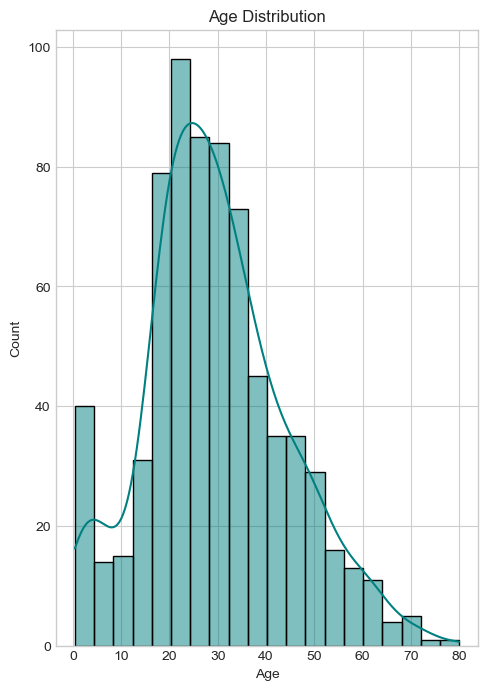

In [21]:
# Histogram with KDE
plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True, color='teal')
plt.title('Age Distribution', fontsize=12)
plt.xlabel('Age')

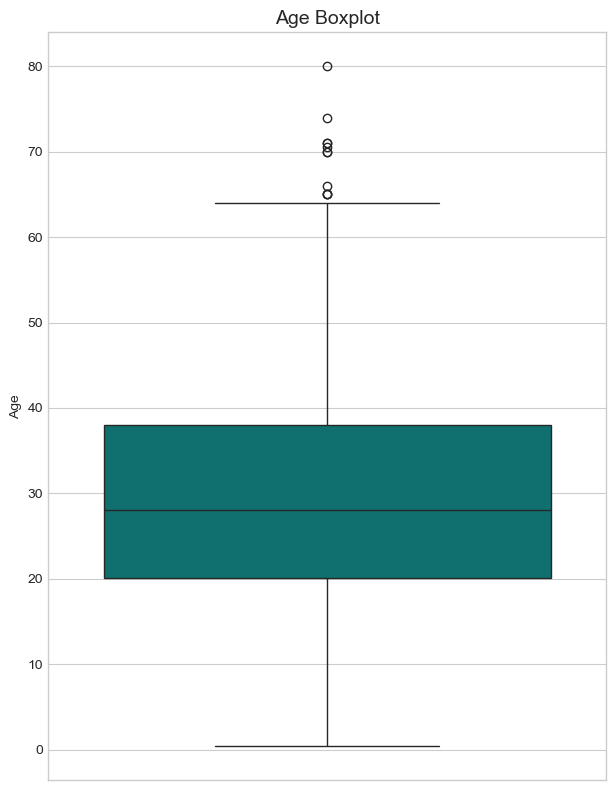

In [22]:
# Bocplot
plt.subplot(1,2,2)
sns.boxplot(df['Age'].dropna(), color='teal')
plt.title('Age Boxplot', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
# Distribution of fare
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Fare')

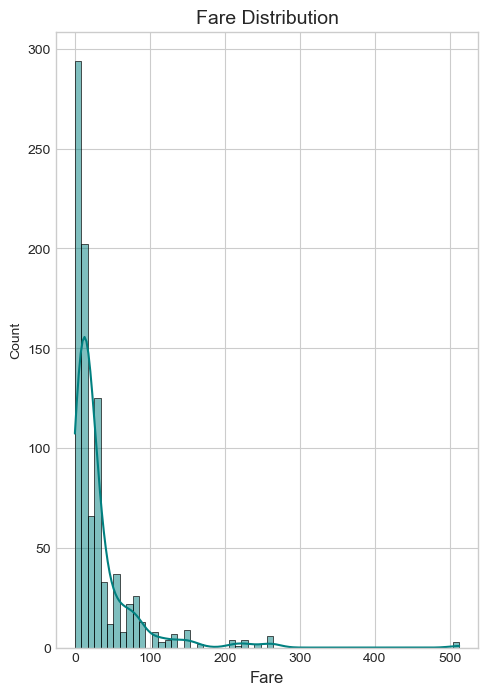

In [24]:
plt.subplot(1,2,1)
sns.histplot(df['Fare'], kde=True, color='teal')
plt.title('Fare Distribution', fontsize=14)
plt.xlabel('Fare', fontsize=12)

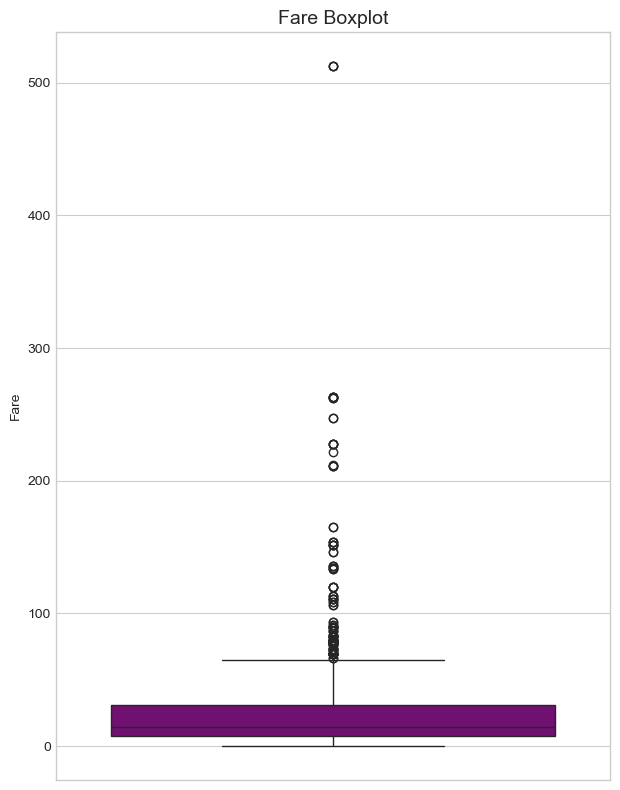

In [25]:
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'], color='purple')
plt.title('Fare Boxplot', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# Categorical value counts with visualization
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

Text(0.5, 1.0, 'Passenger Class Distribution')

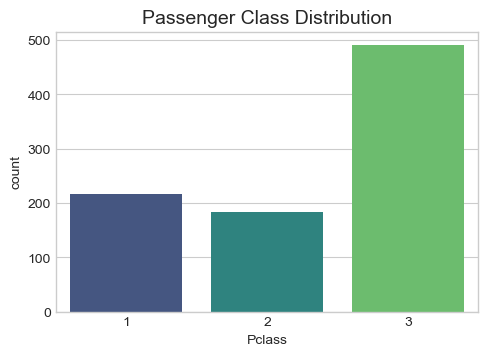

In [27]:
plt.subplot(2,2,1)
sns.countplot(x='Pclass', data=df, color='teal', palette='viridis')
plt.title('Passenger Class Distribution', fontsize=14)

Text(0.5, 1.0, 'Gender Distribution')

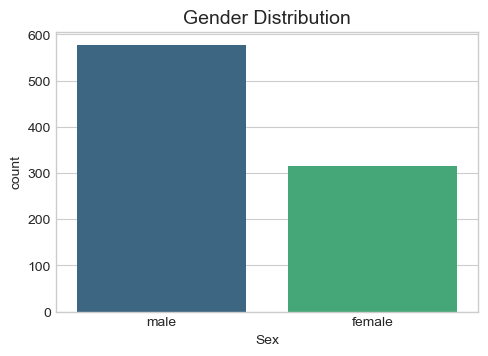

In [28]:
plt.subplot(2,2,1)
sns.countplot(x='Sex', data=df, color='teal', palette='viridis')
plt.title('Gender Distribution', fontsize=14)

Text(0.5, 1.0, 'Embarked Distribution')

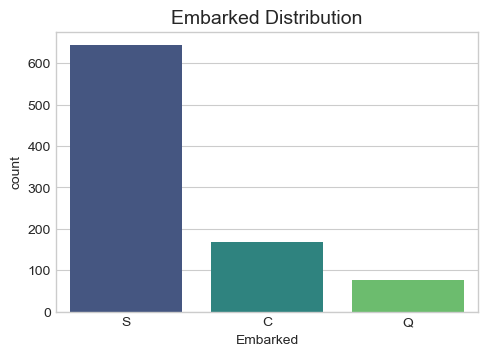

In [29]:
# Embarked Distribution 
plt.subplot(2,2,1)
sns.countplot(x='Embarked', data=df, color='teal', palette='viridis')
plt.title('Embarked Distribution', fontsize=14)

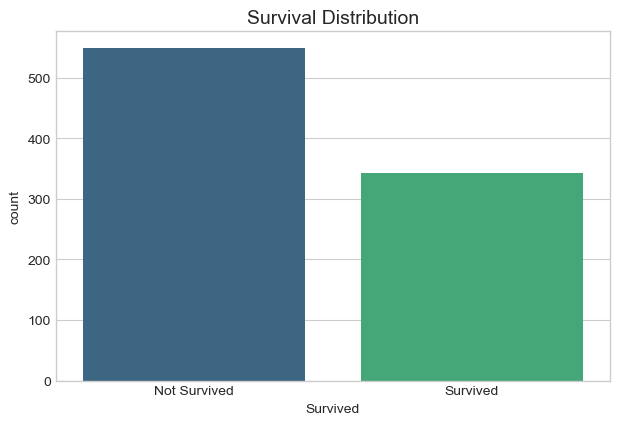

In [30]:
# Survival distribution
plt.subplot(2, 2, 4)
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Distribution', fontsize=14)
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()

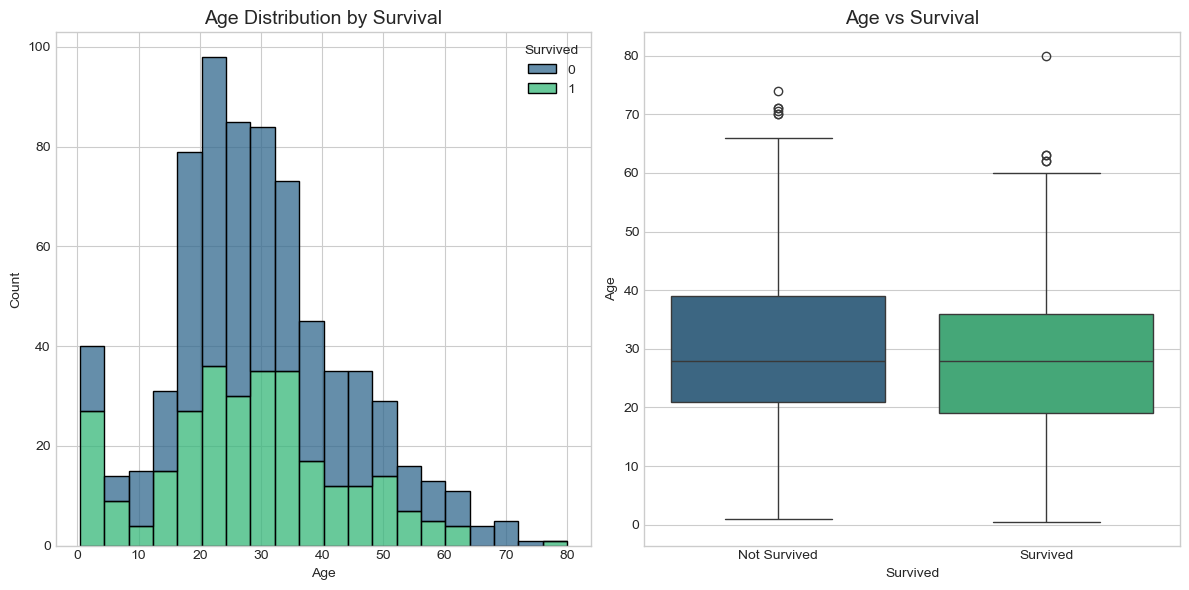

In [31]:
# Bivariate Analysis
# Age distribution by survival status
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette='viridis')
plt.title('Age Distribution by Survival', fontsize=14)

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')
plt.title('Age vs Survival', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()


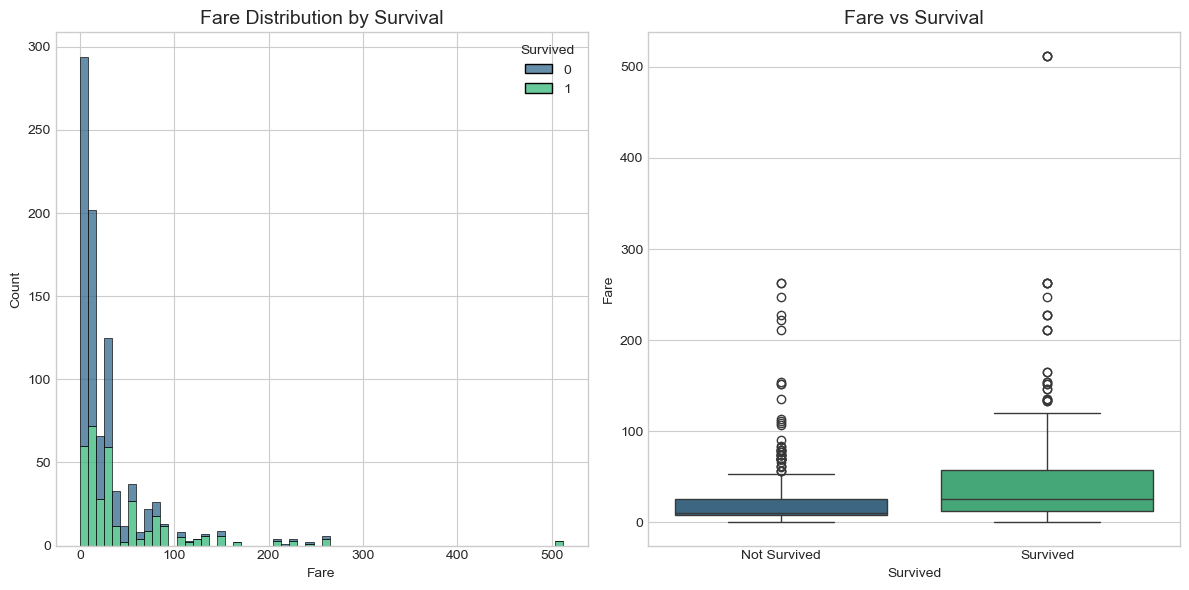

In [32]:
# Bivariate Analysis
# Fare distribution by survival status
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Fare', hue='Survived', multiple='stack', palette='viridis')
plt.title('Fare Distribution by Survival', fontsize=14)

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')
plt.title('Fare vs Survival', fontsize=14)
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

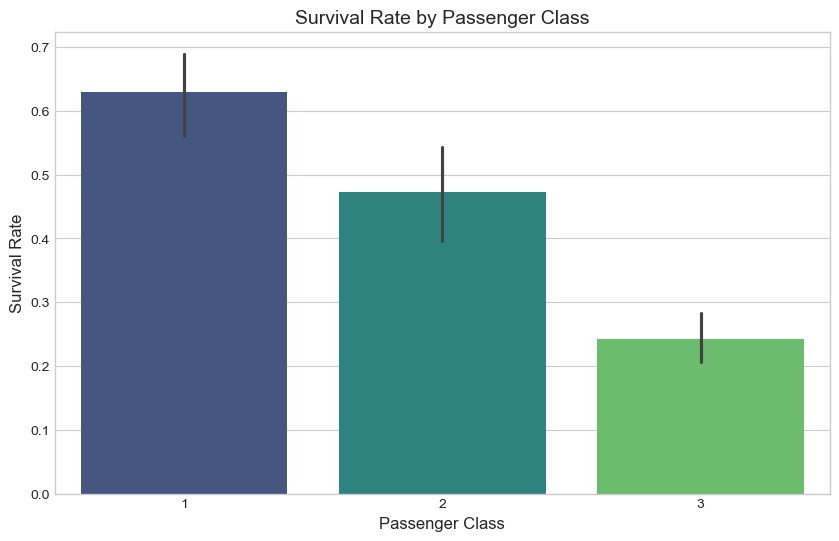

In [33]:
# Survival rate by Passenger Class
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

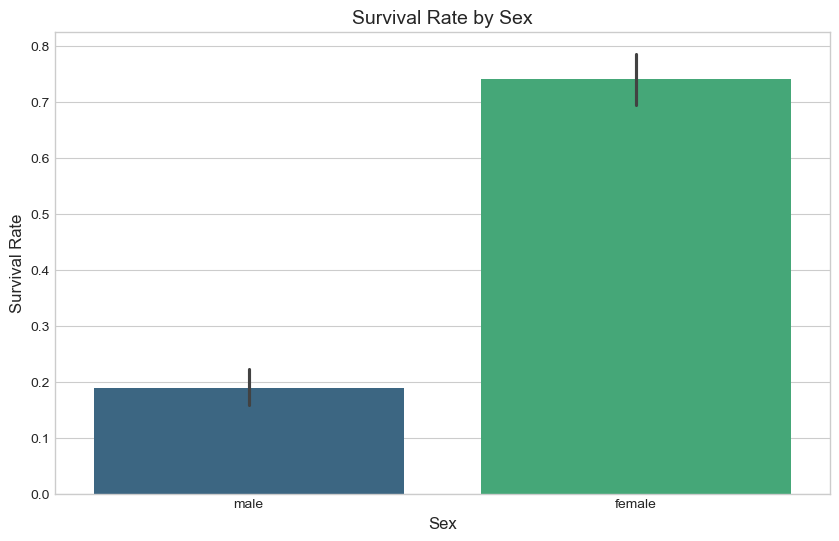

In [34]:
# Survival rate by Sex
plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Sex', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

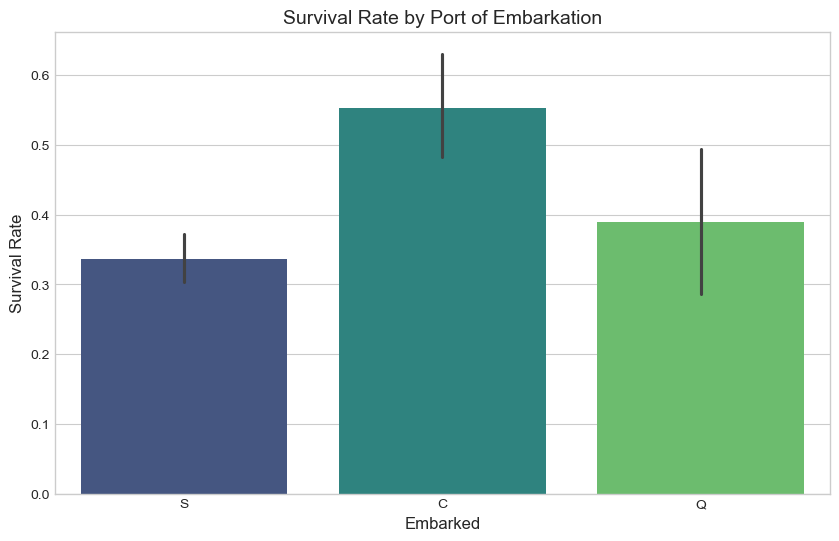

In [35]:
# Survival rate by Embarked
plt.figure(figsize=(10, 6))
sns.barplot(x='Embarked', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Port of Embarkation', fontsize=14)
plt.xlabel('Embarked', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

In [36]:
# Create a correlation matrix for numerical variables
# Fill missing values for correlation calculation

df_corr = df.select_dtypes(include=['int','float64']).copy()
df_corr.fillna(df_corr.mean(), inplace=True)

In [37]:
# Calculate the correlation matrix
corr_matrix = df_corr.corr()

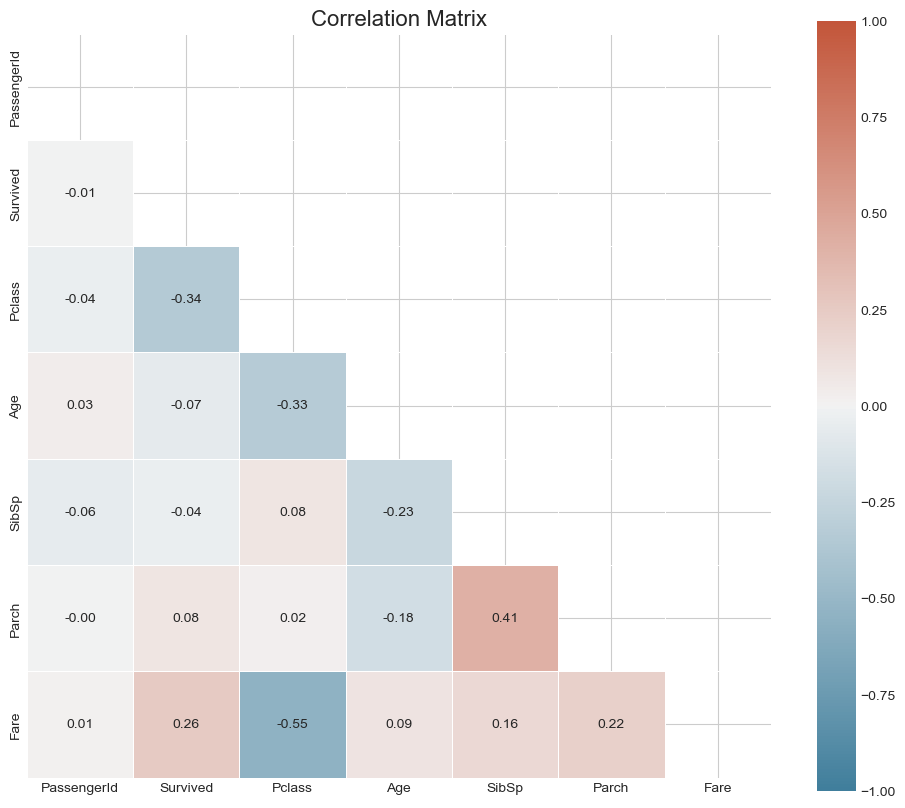

In [38]:
# Visualize correlation matrix
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0, square=True, linewidths=.5, annot=True, fmt='.2f',cbar={'shrink': .5})
plt.title('Correlation Matrix', fontsize=16)
plt.show()

# End result: A triangular heatmap showing pairwise correlations between all numeric variables, color-coded (blue = negative, red = positive,
# white/neutral = near zero), with exact values labeled — a very standard and effective way to spot strongly correlated variables during EDA.

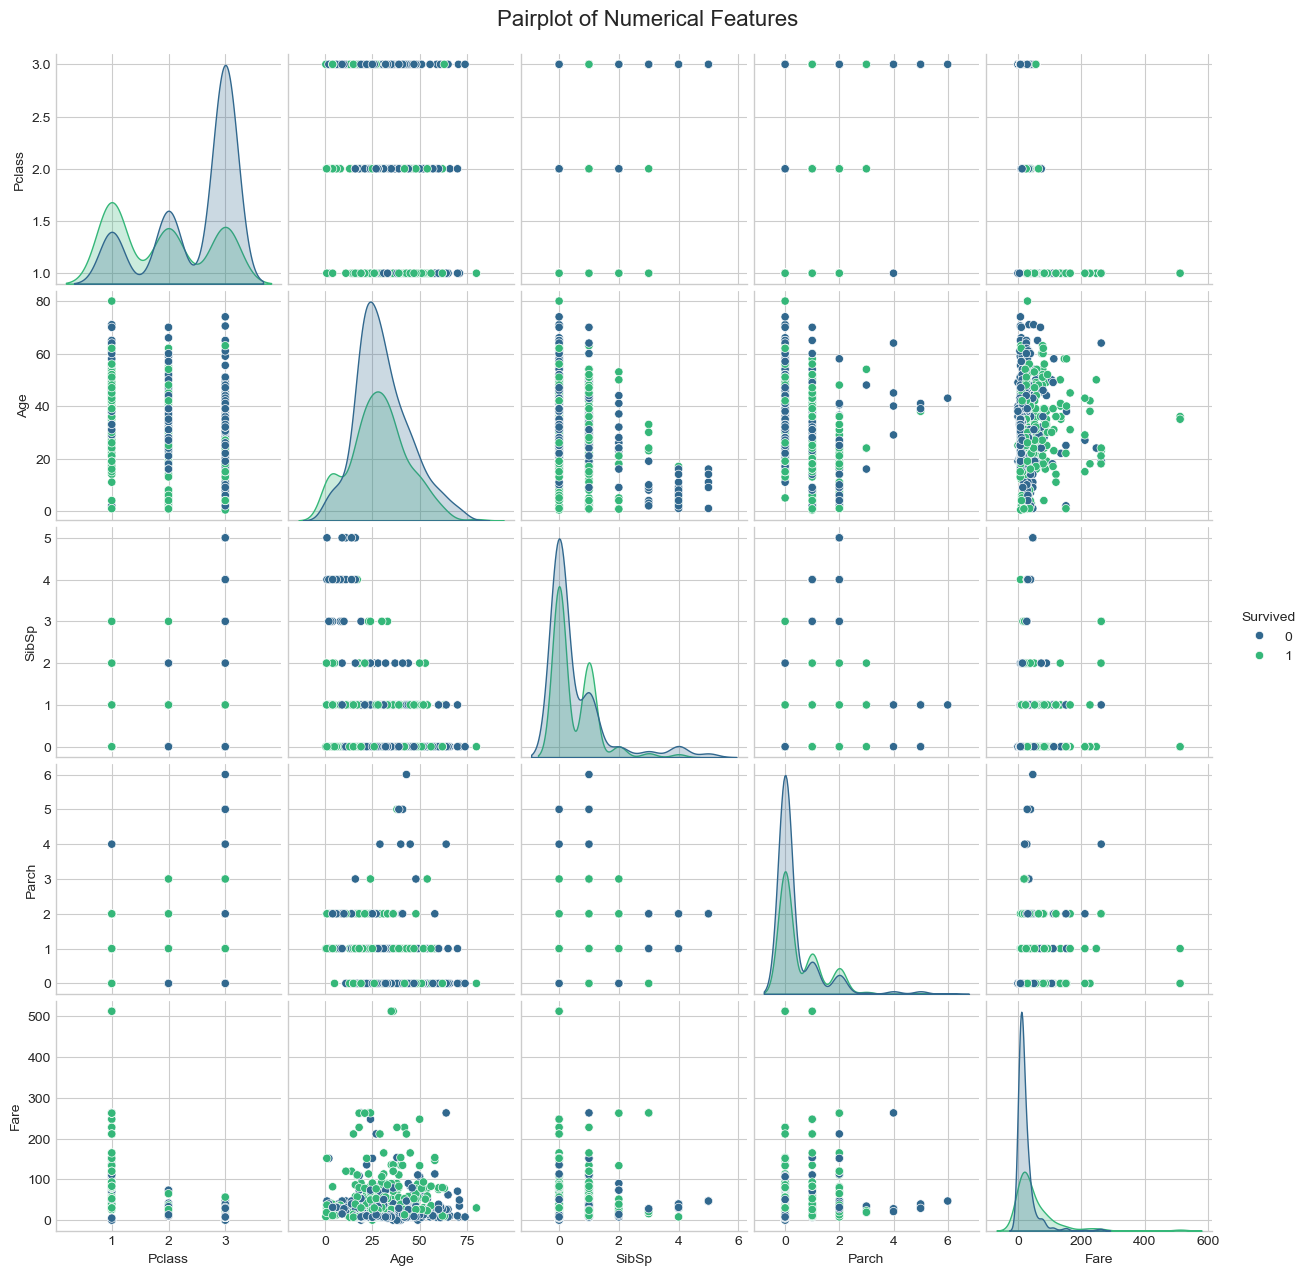

In [39]:
# Pairplot for numerical variables
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna(),
             hue='Survived', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features', y=1.02, fontsize=16)
plt.show()

In [40]:
# Outlier Detection using Z-Score for Fare

z_scores = stats.zscore(df['Fare'].dropna())
outliers_z = np.abs(z_scores) > 3
print(f'Number of outliers detected by Z-score (|z|>3) : {outliers_z.sum()}')

Number of outliers detected by Z-score (|z|>3) : 20


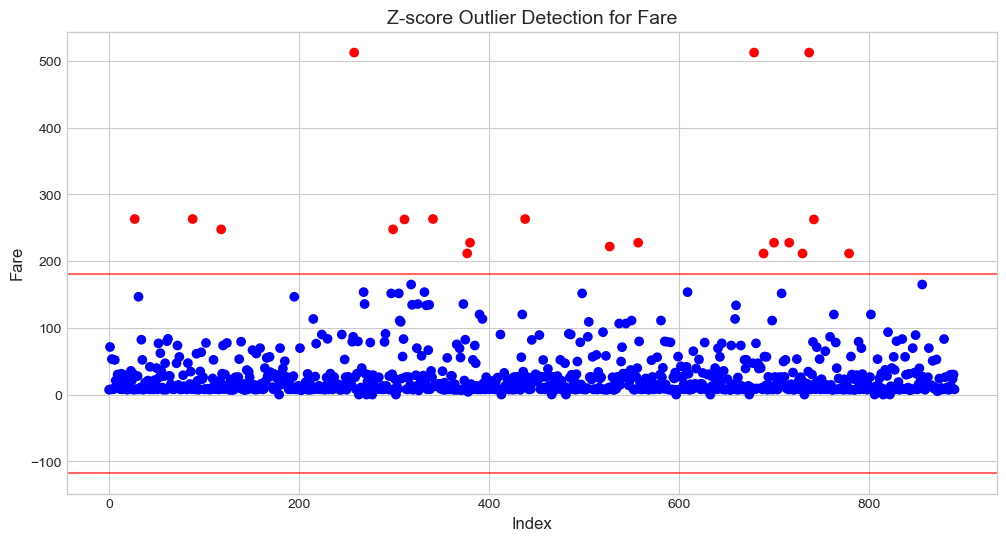

In [41]:
plt.figure(figsize=(12,6))
plt.scatter(range(len(df['Fare'].dropna())), df['Fare'].dropna(), c = ['red' if x else 'blue' for x in outliers_z])
plt.axhline(y=df['Fare'].mean() + 3*df['Fare'].std(), color='red', linestyle='-', alpha=0.6)
plt.axhline(y=df['Fare'].mean() - 3*df['Fare'].std(), color='red', linestyle='-', alpha=0.6
           )
plt.title('Z-score Outlier Detection for Fare', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.show()

In [42]:
# Outlier detection using IQR method for Fare
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = (df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)
print(f"Numbers of outliers detected by IQR method : {outliers_iqr.sum()}")

Numbers of outliers detected by IQR method : 116


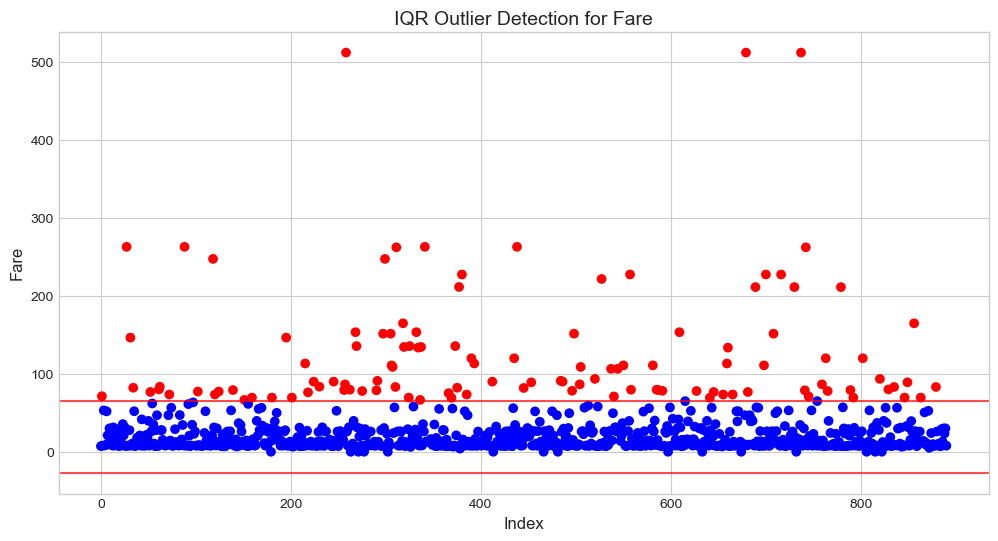

In [43]:
# Visualize IQR outliers
plt.figure(figsize=(12, 6))
plt.scatter(range(len(df['Fare'])), df['Fare'], c=['red' if x else 'blue' for x in outliers_iqr])
plt.axhline(y=upper_bound, color='red', linestyle='-', alpha=0.7)
plt.axhline(y=lower_bound, color='red', linestyle='-', alpha=0.7)
plt.title('IQR Outlier Detection for Fare', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.show()

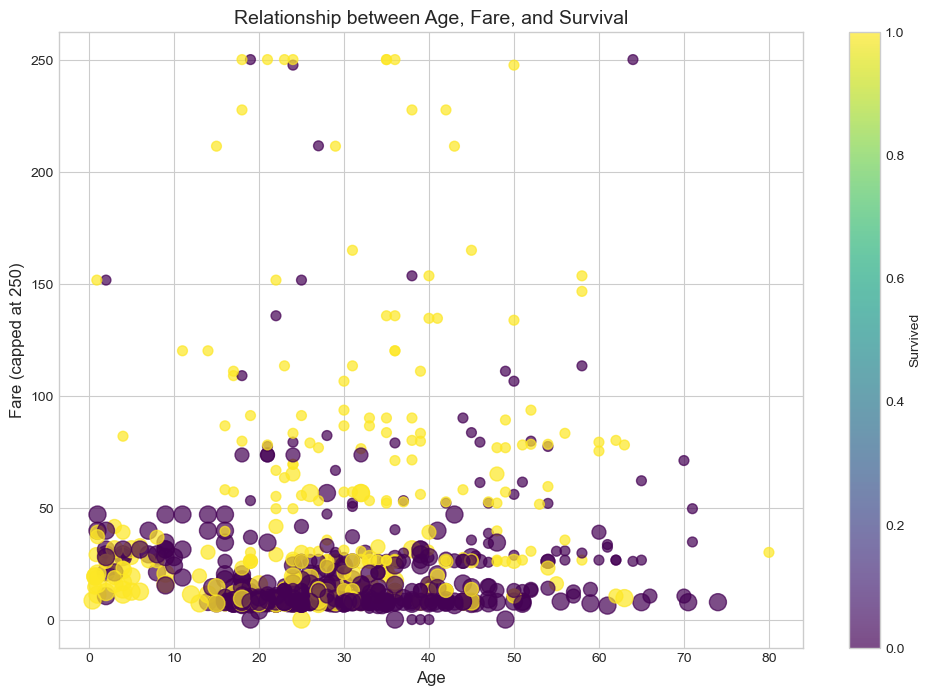

In [44]:
# Visualize relationship between age, fare, and survival
plt.figure(figsize=(12, 8))

# Filter the dataframe to use only rows where Age is not null
age_data = df.dropna(subset=['Age'])

scatter = plt.scatter(age_data['Age'],
                      age_data['Fare'].clip(upper=250),
                      c=age_data['Survived'],
                      cmap='viridis',
                      alpha=0.7,
                      s=age_data['Pclass']*50)

plt.colorbar(scatter, label='Survived')
plt.title('Relationship between Age, Fare, and Survival', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare (capped at 250)', fontsize=12)
plt.show()

In [45]:
# Fearure Engineering Example : 
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Elderly'])

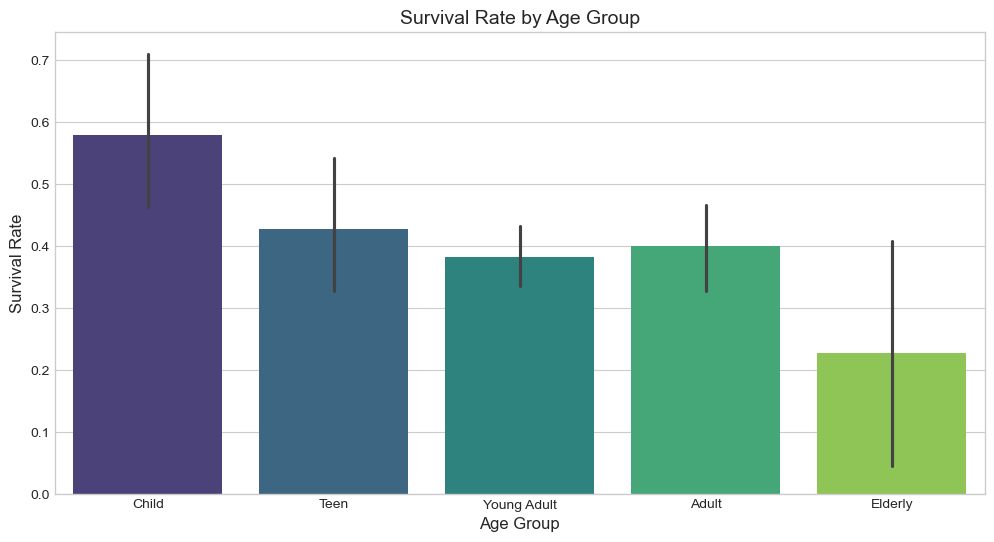

In [46]:
# Survival rate by Age Group
plt.figure(figsize=(12, 6))
sns.barplot(x='AgeGroup', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

In [47]:
# Feature Engineering Example - Fare Categories
df['FareCategory'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

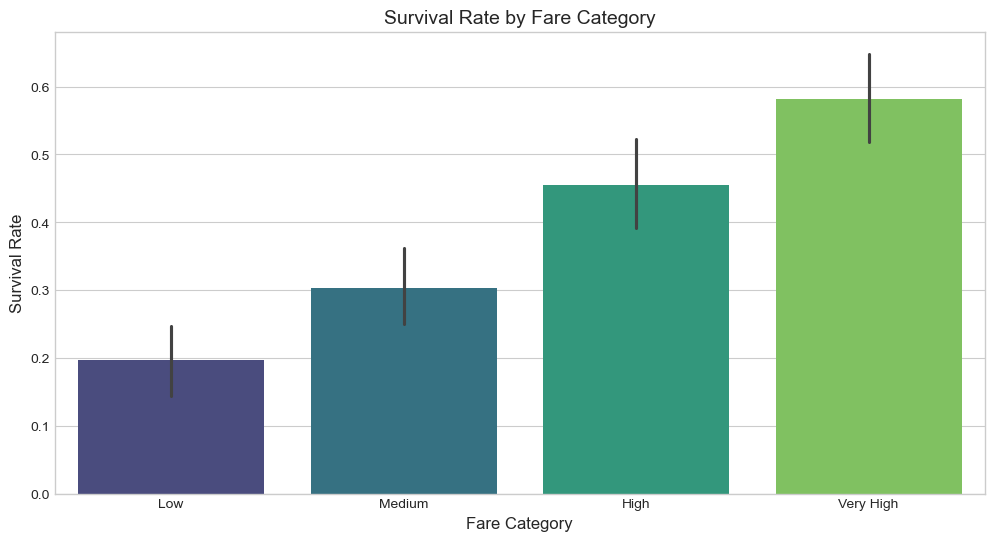

In [48]:
# Survival rate by Fare Category
plt.figure(figsize=(12, 6))
sns.barplot(x='FareCategory', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Fare Category', fontsize=14)
plt.xlabel('Fare Category', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()


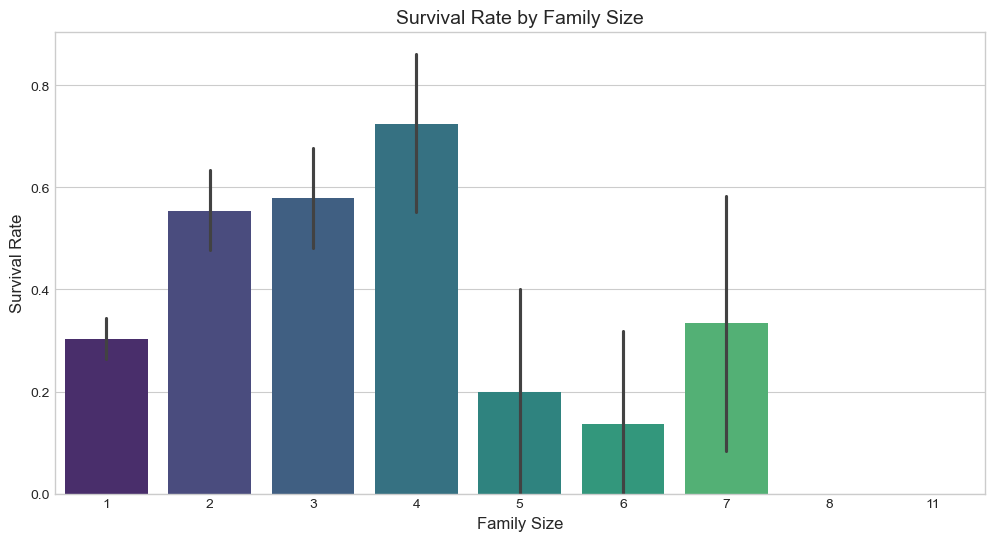

In [49]:
# Family Size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

# Survival rate by Family Size
plt.figure(figsize=(12, 6))
sns.barplot(x='FamilySize', y='Survived', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Family Size', fontsize=14)
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

# Exercise 

In [ ]:
# EDA CHALLENGE

# INSTRUCTIONS:
# 1. Create an analysis that explores whether a passenger's title (Mr, Mrs, Miss, etc.)
#    affected their survival chances on the Titanic.
# 2. Extract titles from the Name column
# 3. Group similar titles (optional)
# 4. Create appropriate visualizations to show the relationship between title and survival
# 5. Calculate and interpret relevant statistics
# 6. Draw conclusions based on your findings

In [68]:
# Extract titles from passenger names 
df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.',expand=False)

In [71]:
# Preview the titles :
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [101]:
# Grouping similar titles : 

# Step 1: Standardize titles that mean the same thing but are spelled differently
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme' : 'Mrs'})

In [106]:
df['Title'].value_counts()

Title
Mr          517
Miss        185
Mrs         126
Master       40
Dr            7
Rev           6
Major         2
Col           2
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [109]:
# Step 2: Bucket all remaining rare titles into a single 'Rare' category
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Countess', 'Capt', 'Jonkheer', 'Sir', 'Lady', 'Don']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

In [111]:
df['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [113]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='Title', ylabel='Survived'>

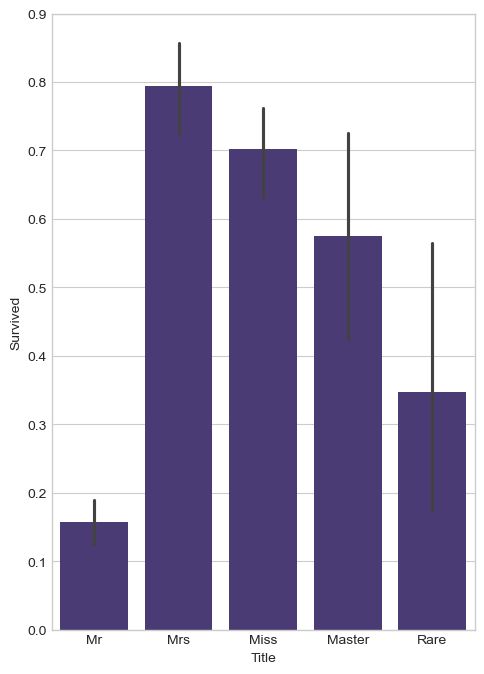

In [118]:
plt.subplot(1,2,1)
sns.barplot(x=df['Title'], y=df['Survived'],estimator=np.mean)

In [119]:
# 3. Calculate relevant statistics (survival rate by title)

title_survival = df.groupby('Title')['Survived'].agg(['mean', 'count', 'sum'])
title_survival.columns = ['Survival Rate', 'Total Passengers', 'Survivors']
title_survival = title_survival.sort_values('Survival Rate', ascending=False)

title_survival

,Survival Rate,Total Passengers,Survivors
Title,,,
Mrs,0.793651,126,100
Miss,0.702703,185,130
Master,0.575000,40,23
Rare,0.347826,23,8
Mr,0.156673,517,81


# Survival rates varied sharply by title, closely following the "women and children first" pattern. Mrs (79.4%) and Miss (70.3%) had the highest survival rates, followed by Master (57.5%) — young boys. Mr had by far the lowest rate at just 15.7%, despite being the largest group (517 passengers). Notably, Master survived at a much higher rate than Mr, even though both are male, suggesting Title captures age-related priority beyond gender alone. The Rare category (34.8%) should be read cautiously, given its small sample size of only 23 passengers. Overall, being female or a young boy was strongly linked to survival, while adult men were far less likely to make it.


In [121]:
# Combine title with Pclass for deeper analysis

# 1. Grouped statistics: survival rate by Title AND Pclass
title_pclass_survival = df.groupby(['Title', 'Pclass'])['Survived'].agg(['mean', 'count'])
title_pclass_survival.columns = ['Survival Rate', 'Total Passengers']
title_pclass_survival = title_pclass_survival.sort_values('Survival Rate', ascending=False)

title_pclass_survival

Survival Rate  Total Passengers
Title  Pclass                                 
Master 1            1.000000                 3
       2            1.000000                 9
Mrs    1            0.976744                43
Miss   1            0.958333                48
       2            0.942857                35
Mrs    2            0.902439                41
Rare   1            0.533333                15
Miss   3            0.500000               102
Mrs    3            0.500000                42
Master 3            0.392857                28
Mr     1            0.345794               107
       3            0.112853               319
       2            0.087912                91
Rare   2            0.000000                 8

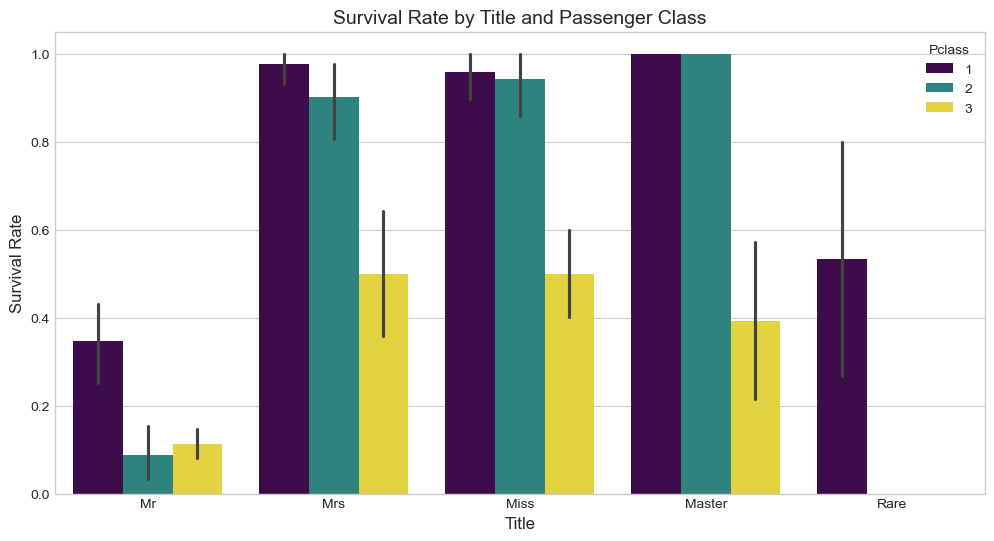

In [122]:
# 2. Visualization: survival rate by Title, split by Pclass
plt.figure(figsize=(12, 6))
sns.barplot(x='Title', y='Survived', hue='Pclass', data=df, estimator=np.mean, palette='viridis')
plt.title('Survival Rate by Title and Passenger Class', fontsize=14)
plt.xlabel('Title', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.legend(title='Pclass')
plt.show()

In [ ]:
# np.random.normal(1,2,5)